# **House Price Prediction using Machine Learning**

**Importing Libraries**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Dataset**

In [28]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Basic Understanding of dataset**

In [29]:
train.shape
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Target Variable Analysis (Sale Price)**

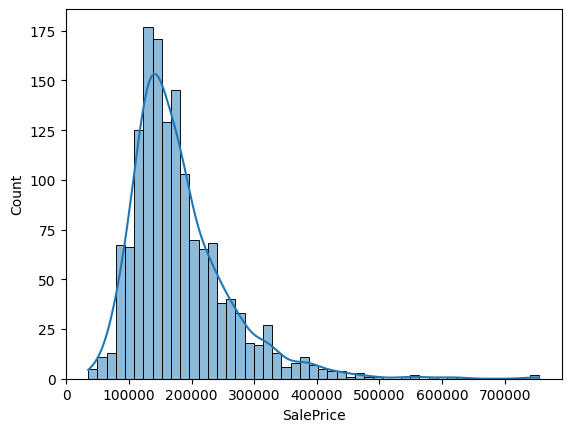

In [30]:
sns.histplot(train['SalePrice'], kde=True)
plt.show()

**Separating Target & Features**

In [31]:
y = train['SalePrice']
X = train.drop(['SalePrice'], axis=1)

**Checking Missing Values**

In [32]:
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


**Handling Missing Values**

In [33]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Fill numerical missing values
for col in num_cols:
    X[col].fillna(X[col].median(), inplace=True)
    test[col].fillna(test[col].median(), inplace=True)

# Fill categorical missing values
for col in cat_cols:
    X[col].fillna("None", inplace=True)
    test[col].fillna("None", inplace=True)

/tmp/ipykernel_7367/227637326.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)
/tmp/ipykernel_7367/227637326.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

**Encoding Categorical Variables**

In [34]:
X = pd.get_dummies(X)
test = pd.get_dummies(test)

**Aliging Train & Test**

In [36]:
X, test = X.align(test, join='left', axis=1, fill_value=0)

In [37]:
y = np.log1p(y)

**Train-Test Split**

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model 1 Linear Regression (Baseline)**

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

preds = lr.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 0.13213775360558563


**Model 2 Random Forest (Better Model)**

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
print("Random Forest RMSE:", rmse)

Random Forest RMSE: 0.1461414941234927


**Final Predictions**

In [41]:
final_preds = rf.predict(test)
final_preds = np.expm1(final_preds)

**Creating Submission File**

In [43]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": final_preds
})

submission.to_csv("submission.csv", index=False)
print('Submission file created successfully!')
print(submission.head())

Submission file created successfully!
     Id      SalePrice
0  1461  124523.461710
1  1462  151744.888934
2  1463  179842.677424
3  1464  183797.113811
4  1465  200641.840147


**Using more upgraded model XgBoost Model**

In [44]:
!pip install xgboost

**Training XgBoost Model**

In [45]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

preds = xgb.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
print("XGBoost RMSE:", rmse)

XGBoost RMSE: 0.13766084720042054


**Comparing all 3 Modles Results**

In [46]:
print("Linear Regression RMSE:", lr_rmse if 'lr_rmse' in locals() else "done above")
print("Random Forest RMSE:", rf_rmse if 'rf_rmse' in locals() else "done above")
print("XGBoost RMSE:", rmse)

Linear Regression RMSE: done above
Random Forest RMSE: done above
XGBoost RMSE: 0.13766084720042054


**Final Predictions**

In [47]:
final_preds = xgb.predict(test)
final_preds = np.expm1(final_preds)

**UPDATED SUBMISSION FILE**

In [48]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": final_preds
})

submission.to_csv("submission.csv", index=False)
print('Submission file created successfully!')
print(submission.head())

Submission file created successfully!
     Id      SalePrice
0  1461  128103.796875
1  1462  163722.406250
2  1463  183568.375000
3  1464  187379.359375
4  1465  194628.687500
